## Матричная факторизация (SVD)
Используем скрытые факторы для рекомендаций.

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from surprise.accuracy import rmse


## Загрузка данных
Загружаем датасет MovieLens и подготавливаем его для анализа.

In [73]:
movies = pd.read_csv("data/movies.csv")
ratings = pd.read_csv("data/ratings.csv")

print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)

Movies shape: (9742, 3)
Ratings shape: (100836, 4)


## Первичный анализ (EDA)
Изучаем структуру данных и основные характеристики датасета.

In [74]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [75]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [76]:
print("Количество пользователей:", ratings['userId'].nunique())
print("Количество фильмов:", ratings['movieId'].nunique())
print("Количество оценок:", len(ratings))

Количество пользователей: 610
Количество фильмов: 9724
Количество оценок: 100836


## Разреженность матрицы
Анализируем плотность user-item матрицы — ключевую проблему рекомендательных систем.

In [77]:
num_users = ratings['userId'].nunique()
num_movies = ratings['movieId'].nunique()

sparsity = 1 - len(ratings) / (num_users * num_movies)

print(f"Разреженность матрицы: {sparsity:.4f}")

Разреженность матрицы: 0.9830


## Визуализация данных
Исследуем распределение рейтингов и активность пользователей.

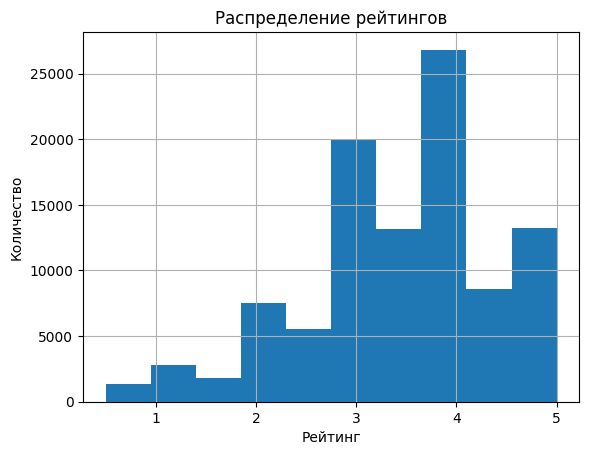

In [78]:
ratings['rating'].hist(bins=10)
plt.title("Распределение рейтингов")
plt.xlabel("Рейтинг")
plt.ylabel("Количество")
plt.show()

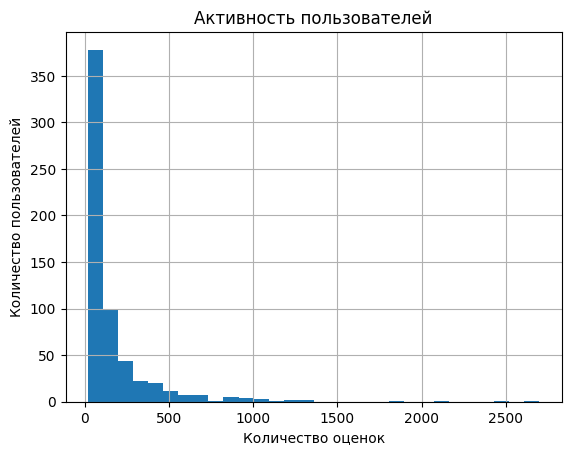

In [79]:
user_activity = ratings.groupby('userId')['rating'].count()

user_activity.hist(bins=30)
plt.title("Активность пользователей")
plt.xlabel("Количество оценок")
plt.ylabel("Количество пользователей")
plt.show()

## Baseline модель
Строим простую модель на основе популярности фильмов.

In [80]:
movie_stats = ratings.groupby('movieId').agg({
    'rating': ['mean', 'count']
})

movie_stats.columns = ['avg_rating', 'num_ratings']
movie_stats = movie_stats.reset_index()

movie_stats.head()

,movieId,avg_rating,num_ratings
0,1,3.920930,215
1,2,3.431818,110
2,3,3.259615,52
3,4,2.357143,7
4,5,3.071429,49


In [81]:
movie_stats = movie_stats.merge(movies, on='movieId')

movie_stats.head()

,movieId,avg_rating,num_ratings,title,genres
0,1,3.920930,215,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,3.431818,110,Jumanji (1995),Adventure|Children|Fantasy
2,3,3.259615,52,Grumpier Old Men (1995),Comedy|Romance
3,4,2.357143,7,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,3.071429,49,Father of the Bride Part II (1995),Comedy


In [82]:
top_movies = movie_stats.sort_values(
    by=['avg_rating', 'num_ratings'],
    ascending=False
)

top_movies[['title', 'avg_rating', 'num_ratings']].head(10)

,title,avg_rating,num_ratings
48,Lamerica (1994),5.0,2
87,Heidi Fleiss: Hollywood Madam (1995),5.0,2
869,Lesson Faust (1994),5.0,2
2593,Jonah Who Will Be 25 in the Year 2000 (Jonas q...,5.0,2
4384,Belle époque (1992),5.0,2
4583,Come and See (Idi i smotri) (1985),5.0,2
7347,Enter the Void (2009),5.0,2
121,"Awfully Big Adventure, An (1995)",5.0,1
405,Live Nude Girls (1995),5.0,1
432,In the Realm of the Senses (Ai no corrida) (1976),5.0,1


In [83]:
popular_movies = movie_stats[movie_stats['num_ratings'] > 50]

top_movies = popular_movies.sort_values(
    by='avg_rating',
    ascending=False
)

top_movies[['title', 'avg_rating', 'num_ratings']].head(10)

,title,avg_rating,num_ratings
277,"Shawshank Redemption, The (1994)",4.429022,317
659,"Godfather, The (1972)",4.289062,192
2224,Fight Club (1999),4.272936,218
974,Cool Hand Luke (1967),4.271930,57
602,Dr. Strangelove or: How I Learned to Stop Worr...,4.268041,97
686,Rear Window (1954),4.261905,84
921,"Godfather: Part II, The (1974)",4.259690,129
6298,"Departed, The (2006)",4.252336,107
913,Goodfellas (1990),4.250000,126
694,Casablanca (1942),4.240000,100


In [84]:
def recommend_popular(n=10, min_ratings=50):
    popular_movies = movie_stats[movie_stats['num_ratings'] > min_ratings]
    top_movies = popular_movies.sort_values(by='avg_rating', ascending=False)
    return top_movies[['title', 'avg_rating', 'num_ratings']].head(n)

In [85]:
recommend_popular(10)

,title,avg_rating,num_ratings
277,"Shawshank Redemption, The (1994)",4.429022,317
659,"Godfather, The (1972)",4.289062,192
2224,Fight Club (1999),4.272936,218
974,Cool Hand Luke (1967),4.271930,57
602,Dr. Strangelove or: How I Learned to Stop Worr...,4.268041,97
686,Rear Window (1954),4.261905,84
921,"Godfather: Part II, The (1974)",4.259690,129
6298,"Departed, The (2006)",4.252336,107
913,Goodfellas (1990),4.250000,126
694,Casablanca (1942),4.240000,100


In [86]:
movies['genres'] = movies['genres'].fillna('')
movies[['movieId', 'title', 'genres']].head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## Content-based рекомендации
Используем жанры фильмов для построения рекомендаций.

In [87]:
genres_dummies = movies['genres'].str.get_dummies(sep='|')
genres_dummies.head()

,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [88]:
movie_similarity = cosine_similarity(genres_dummies.values)
movie_similarity = np.array(movie_similarity)

print(movie_similarity.shape)
print(type(movie_similarity))

(9742, 9742)
<class 'numpy.ndarray'>


In [89]:
movies = movies.reset_index(drop=True)

movie_indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()
movie_indices.head()

title
Toy Story (1995)                      0
Jumanji (1995)                        1
Grumpier Old Men (1995)               2
Waiting to Exhale (1995)              3
Father of the Bride Part II (1995)    4
dtype: int64

In [90]:
def recommend_similar_movies(title, n=10):
    idx = movie_indices[title]
    sim_scores = list(enumerate(movie_similarity[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:n+1]  # убираем сам фильм

    movie_idxs = [i[0] for i in sim_scores]

    return movies.iloc[movie_idxs][['title', 'genres']]

In [91]:
recommend_similar_movies("Toy Story (1995)", 10)

,title,genres
1706,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy
2355,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy
2809,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy
3000,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy
3568,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy
6194,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy
6486,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy
6948,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy
7760,Asterix and the Vikings (Astérix et les Viking...,Adventure|Animation|Children|Comedy|Fantasy
8219,Turbo (2013),Adventure|Animation|Children|Comedy|Fantasy


In [92]:
def get_user_liked_movies(user_id, min_rating=4.0):
    user_ratings = ratings[ratings['userId'] == user_id]
    liked = user_ratings[user_ratings['rating'] >= min_rating]
    liked = liked.merge(movies, on='movieId')
    return liked[['movieId', 'title', 'rating', 'genres']].sort_values(by='rating', ascending=False)

In [93]:
get_user_liked_movies(1).head(10)

,movieId,title,rating,genres
199,5060,M*A*S*H (a.k.a. MASH) (1970),5.0,Comedy|Drama|War
165,2987,Who Framed Roger Rabbit? (1988),5.0,Adventure|Animation|Children|Comedy|Crime|Fant...
169,3033,Spaceballs (1987),5.0,Comedy|Sci-Fi
90,1804,"Newton Boys, The (1998)",5.0,Crime|Drama
167,2993,Thunderball (1965),5.0,Action|Adventure|Thriller
93,1927,All Quiet on the Western Front (1930),5.0,Action|Drama|War
94,1954,Rocky (1976),5.0,Drama
166,2991,Live and Let Die (1973),5.0,Action|Adventure|Thriller
97,2005,"Goonies, The (1985)",5.0,Action|Adventure|Children|Comedy|Fantasy
68,1240,"Terminator, The (1984)",5.0,Action|Sci-Fi|Thriller


In [94]:
def recommend_for_user_content(user_id, top_n=10, min_rating=4.0):
    liked_movies = get_user_liked_movies(user_id, min_rating=min_rating)

    if liked_movies.empty:
        return pd.DataFrame(columns=['movieId', 'title', 'genres', 'score'])

    watched_movie_ids = set(ratings[ratings['userId'] == user_id]['movieId'])
    scores = {}

    for _, row in liked_movies.iterrows():
        title = row['title']

        if title not in movie_indices:
            continue

        idx = movie_indices[title]

        sim_scores = list(enumerate(movie_similarity[idx].ravel()))

        for movie_idx, sim_score in sim_scores:
            candidate_movie_id = movies.iloc[movie_idx]['movieId']

            if candidate_movie_id in watched_movie_ids:
                continue

            scores[movie_idx] = scores.get(movie_idx, 0.0) + float(sim_score)

    if len(scores) == 0:
        return pd.DataFrame(columns=['movieId', 'title', 'genres', 'score'])

    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]

    movie_idxs = [x[0] for x in sorted_scores]
    movie_scores = [x[1] for x in sorted_scores]

    recommendations = movies.iloc[movie_idxs][['movieId', 'title', 'genres']].copy()
    recommendations['score'] = movie_scores

    return recommendations.sort_values(by='score', ascending=False).reset_index(drop=True)

In [95]:
recommend_for_user_content(user_id=1, top_n=10)

,movieId,title,genres,score
0,117646,Dragonheart 2: A New Beginning (2000),Action|Adventure|Comedy|Drama|Fantasy|Thriller,86.830939
1,55116,"Hunting Party, The (2007)",Action|Adventure|Comedy|Drama|Thriller,85.269952
2,5657,Flashback (1990),Action|Adventure|Comedy|Crime|Drama,84.365006
3,6990,The Great Train Robbery (1978),Action|Adventure|Comedy|Crime|Drama,84.365006
4,4956,"Stunt Man, The (1980)",Action|Adventure|Comedy|Drama|Romance|Thriller,83.540977
5,4818,Extreme Days (2001),Action|Adventure|Comedy|Drama,83.290856
6,42015,Casanova (2005),Action|Adventure|Comedy|Drama|Romance,80.742209
7,2890,Three Kings (1999),Action|Adventure|Comedy|Drama|War,79.813360
8,82765,Little Big Soldier (Da bing xiao jiang) (2010),Action|Adventure|Comedy|Drama|War,79.813360
9,26236,"White Sun of the Desert, The (Beloe solntse pu...",Action|Adventure|Comedy|Drama|Romance|War,78.559813


## Collaborative Filtering
Строим рекомендации на основе похожести пользователей.

In [96]:
user_movie_matrix = ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

user_movie_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [97]:
user_movie_matrix.shape

(610, 9724)

In [98]:
user_movie_filled = user_movie_matrix.fillna(0)
user_similarity = cosine_similarity(user_movie_filled)
user_similarity.shape

(610, 610)

In [99]:
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_movie_matrix.index,
    columns=user_movie_matrix.index
)

user_similarity_df.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
userId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.027283,0.059720,0.194395,0.129080,0.128152,0.158744,0.136968,0.064263,0.016875,...,0.080554,0.164455,0.221486,0.070669,0.153625,0.164191,0.269389,0.291097,0.093572,0.145321
2,0.027283,1.000000,0.000000,0.003726,0.016614,0.025333,0.027585,0.027257,0.000000,0.067445,...,0.202671,0.016866,0.011997,0.000000,0.000000,0.028429,0.012948,0.046211,0.027565,0.102427
3,0.059720,0.000000,1.000000,0.002251,0.005020,0.003936,0.000000,0.004941,0.000000,0.000000,...,0.005048,0.004892,0.024992,0.000000,0.010694,0.012993,0.019247,0.021128,0.000000,0.032119
4,0.194395,0.003726,0.002251,1.000000,0.128659,0.088491,0.115120,0.062969,0.011361,0.031163,...,0.085938,0.128273,0.307973,0.052985,0.084584,0.200395,0.131746,0.149858,0.032198,0.107683
5,0.129080,0.016614,0.005020,0.128659,1.000000,0.300349,0.108342,0.429075,0.000000,0.030611,...,0.068048,0.418747,0.110148,0.258773,0.148758,0.106435,0.152866,0.135535,0.261232,0.060792


In [100]:
def get_similar_users(user_id, n=5):
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)
    similar_users = similar_users.drop(user_id)  # убираем самого себя
    return similar_users.head(n)

In [101]:
get_similar_users(1, 5)

userId
266    0.357408
313    0.351562
368    0.345127
57     0.345034
91     0.334727
Name: 1, dtype: float64

In [102]:
def recommend_for_user_cf(user_id, top_n=10, n_neighbors=5):
    similar_users = get_similar_users(user_id, n=n_neighbors)
    similar_user_ids = similar_users.index.tolist()

    watched_movie_ids = set(ratings[ratings['userId'] == user_id]['movieId'])

    neighbor_ratings = ratings[ratings['userId'].isin(similar_user_ids)].copy()
    neighbor_ratings = neighbor_ratings[~neighbor_ratings['movieId'].isin(watched_movie_ids)]

    if neighbor_ratings.empty:
        return pd.DataFrame(columns=['movieId', 'title', 'genres', 'score', 'num_ratings_from_neighbors'])

    movie_scores = (
        neighbor_ratings
        .groupby('movieId')
        .agg(score=('rating', 'mean'),
             num_ratings_from_neighbors=('rating', 'count'))
        .reset_index()
    )

    recommendations = movie_scores.merge(movies, on='movieId')
    recommendations = recommendations.sort_values(
        by=['score', 'num_ratings_from_neighbors'],
        ascending=False
    )

    return recommendations[['movieId', 'title', 'genres', 'score', 'num_ratings_from_neighbors']].head(top_n)

In [103]:
recommend_for_user_cf(user_id=1, top_n=10, n_neighbors=5)

,movieId,title,genres,score,num_ratings_from_neighbors
142,541,Blade Runner (1982),Action|Sci-Fi|Thriller,5.0,4
191,858,"Godfather, The (1972)",Crime|Drama,5.0,4
171,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,5.0,3
262,1252,Chinatown (1974),Crime|Film-Noir|Mystery|Thriller,5.0,2
653,3108,"Fisher King, The (1991)",Comedy|Drama|Fantasy|Romance,5.0,2
130,514,"Ref, The (1994)",Comedy,5.0,1
165,720,Wallace & Gromit: The Best of Aardman Animatio...,Adventure|Animation|Comedy,5.0,1
198,899,Singin' in the Rain (1952),Comedy|Musical|Romance,5.0,1
204,913,"Maltese Falcon, The (1941)",Film-Noir|Mystery,5.0,1
205,915,Sabrina (1954),Comedy|Romance,5.0,1


In [104]:
print("Content-based recommendations:")
display(recommend_for_user_content(user_id=1, top_n=10))

print("Collaborative filtering recommendations:")
display(recommend_for_user_cf(user_id=1, top_n=10, n_neighbors=5))

Content-based recommendations:


,movieId,title,genres,score
0,117646,Dragonheart 2: A New Beginning (2000),Action|Adventure|Comedy|Drama|Fantasy|Thriller,86.830939
1,55116,"Hunting Party, The (2007)",Action|Adventure|Comedy|Drama|Thriller,85.269952
2,5657,Flashback (1990),Action|Adventure|Comedy|Crime|Drama,84.365006
3,6990,The Great Train Robbery (1978),Action|Adventure|Comedy|Crime|Drama,84.365006
4,4956,"Stunt Man, The (1980)",Action|Adventure|Comedy|Drama|Romance|Thriller,83.540977
5,4818,Extreme Days (2001),Action|Adventure|Comedy|Drama,83.290856
6,42015,Casanova (2005),Action|Adventure|Comedy|Drama|Romance,80.742209
7,2890,Three Kings (1999),Action|Adventure|Comedy|Drama|War,79.813360
8,82765,Little Big Soldier (Da bing xiao jiang) (2010),Action|Adventure|Comedy|Drama|War,79.813360
9,26236,"White Sun of the Desert, The (Beloe solntse pu...",Action|Adventure|Comedy|Drama|Romance|War,78.559813


Collaborative filtering recommendations:


,movieId,title,genres,score,num_ratings_from_neighbors
142,541,Blade Runner (1982),Action|Sci-Fi|Thriller,5.0,4
191,858,"Godfather, The (1972)",Crime|Drama,5.0,4
171,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,5.0,3
262,1252,Chinatown (1974),Crime|Film-Noir|Mystery|Thriller,5.0,2
653,3108,"Fisher King, The (1991)",Comedy|Drama|Fantasy|Romance,5.0,2
130,514,"Ref, The (1994)",Comedy,5.0,1
165,720,Wallace & Gromit: The Best of Aardman Animatio...,Adventure|Animation|Comedy,5.0,1
198,899,Singin' in the Rain (1952),Comedy|Musical|Romance,5.0,1
204,913,"Maltese Falcon, The (1941)",Film-Noir|Mystery,5.0,1
205,915,Sabrina (1954),Comedy|Romance,5.0,1


In [105]:
reader = Reader(rating_scale=(ratings['rating'].min(), ratings['rating'].max()))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

In [106]:
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

In [107]:
svd_model = SVD(random_state=42)
svd_model.fit(trainset)

In [108]:
predictions = svd_model.test(testset)
rmse(predictions)

RMSE: 0.8807


0.8807462819979623

In [109]:
def recommend_for_user_svd(user_id, top_n=10):
    watched_movie_ids = set(ratings[ratings['userId'] == user_id]['movieId'])
    all_movie_ids = movies['movieId'].unique()

    predictions = []

    for movie_id in all_movie_ids:
        if movie_id in watched_movie_ids:
            continue

        pred = svd_model.predict(user_id, movie_id)
        predictions.append((movie_id, pred.est))

    pred_df = pd.DataFrame(predictions, columns=['movieId', 'predicted_rating'])
    pred_df = pred_df.merge(movies, on='movieId')
    pred_df = pred_df.sort_values(by='predicted_rating', ascending=False)

    return pred_df[['movieId', 'title', 'genres', 'predicted_rating']].head(top_n)

In [110]:
recommend_for_user_svd(user_id=1, top_n=10)

,movieId,title,genres,predicted_rating
646,908,North by Northwest (1959),Action|Adventure|Mystery|Romance|Thriller,5.0
4297,6711,Lost in Translation (2003),Comedy|Drama|Romance,5.0
2685,3910,Dancer in the Dark (2000),Drama|Musical,5.0
445,541,Blade Runner (1982),Action|Sci-Fi|Thriller,5.0
554,741,Ghost in the Shell (Kôkaku kidôtai) (1995),Animation|Sci-Fi,5.0
560,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,5.0
650,912,Casablanca (1942),Drama|Romance,5.0
6083,48516,"Departed, The (2006)",Crime|Drama|Thriller,5.0
775,1104,"Streetcar Named Desire, A (1951)",Drama,5.0
810,1172,Cinema Paradiso (Nuovo cinema Paradiso) (1989),Drama,5.0


In [111]:
print("Baseline:")
display(recommend_popular(10))

print("Content-based:")
display(recommend_for_user_content(user_id=1, top_n=10))

print("Collaborative filtering:")
display(recommend_for_user_cf(user_id=1, top_n=10, n_neighbors=5))

print("SVD:")
display(recommend_for_user_svd(user_id=1, top_n=10))

Baseline:


,title,avg_rating,num_ratings
277,"Shawshank Redemption, The (1994)",4.429022,317
659,"Godfather, The (1972)",4.289062,192
2224,Fight Club (1999),4.272936,218
974,Cool Hand Luke (1967),4.271930,57
602,Dr. Strangelove or: How I Learned to Stop Worr...,4.268041,97
686,Rear Window (1954),4.261905,84
921,"Godfather: Part II, The (1974)",4.259690,129
6298,"Departed, The (2006)",4.252336,107
913,Goodfellas (1990),4.250000,126
694,Casablanca (1942),4.240000,100


Content-based:


,movieId,title,genres,score
0,117646,Dragonheart 2: A New Beginning (2000),Action|Adventure|Comedy|Drama|Fantasy|Thriller,86.830939
1,55116,"Hunting Party, The (2007)",Action|Adventure|Comedy|Drama|Thriller,85.269952
2,5657,Flashback (1990),Action|Adventure|Comedy|Crime|Drama,84.365006
3,6990,The Great Train Robbery (1978),Action|Adventure|Comedy|Crime|Drama,84.365006
4,4956,"Stunt Man, The (1980)",Action|Adventure|Comedy|Drama|Romance|Thriller,83.540977
5,4818,Extreme Days (2001),Action|Adventure|Comedy|Drama,83.290856
6,42015,Casanova (2005),Action|Adventure|Comedy|Drama|Romance,80.742209
7,2890,Three Kings (1999),Action|Adventure|Comedy|Drama|War,79.813360
8,82765,Little Big Soldier (Da bing xiao jiang) (2010),Action|Adventure|Comedy|Drama|War,79.813360
9,26236,"White Sun of the Desert, The (Beloe solntse pu...",Action|Adventure|Comedy|Drama|Romance|War,78.559813


Collaborative filtering:


,movieId,title,genres,score,num_ratings_from_neighbors
142,541,Blade Runner (1982),Action|Sci-Fi|Thriller,5.0,4
191,858,"Godfather, The (1972)",Crime|Drama,5.0,4
171,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,5.0,3
262,1252,Chinatown (1974),Crime|Film-Noir|Mystery|Thriller,5.0,2
653,3108,"Fisher King, The (1991)",Comedy|Drama|Fantasy|Romance,5.0,2
130,514,"Ref, The (1994)",Comedy,5.0,1
165,720,Wallace & Gromit: The Best of Aardman Animatio...,Adventure|Animation|Comedy,5.0,1
198,899,Singin' in the Rain (1952),Comedy|Musical|Romance,5.0,1
204,913,"Maltese Falcon, The (1941)",Film-Noir|Mystery,5.0,1
205,915,Sabrina (1954),Comedy|Romance,5.0,1


SVD:


,movieId,title,genres,predicted_rating
646,908,North by Northwest (1959),Action|Adventure|Mystery|Romance|Thriller,5.0
4297,6711,Lost in Translation (2003),Comedy|Drama|Romance,5.0
2685,3910,Dancer in the Dark (2000),Drama|Musical,5.0
445,541,Blade Runner (1982),Action|Sci-Fi|Thriller,5.0
554,741,Ghost in the Shell (Kôkaku kidôtai) (1995),Animation|Sci-Fi,5.0
560,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,5.0
650,912,Casablanca (1942),Drama|Romance,5.0
6083,48516,"Departed, The (2006)",Crime|Drama|Thriller,5.0
775,1104,"Streetcar Named Desire, A (1951)",Drama,5.0
810,1172,Cinema Paradiso (Nuovo cinema Paradiso) (1989),Drama,5.0
